205.0 100.0
875.0 100.0
1000.0 500.0
90.0 500.0
Imagen: 1080×601 px | H: (3, 3)


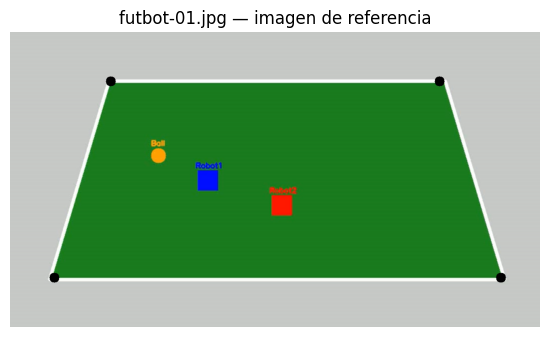

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import supervision as sv
from pathlib import Path

# Cargar imagen de referencia
path = Path.cwd()
DIR_ACTUAL = path / "assets"
image_bgr = cv2.imread(f'{DIR_ACTUAL}/fotos/futbot-03.png')
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


# Recalcular H (mismos puntos que NB10 — notebook standalone)
SOURCE_POINTS = np.float32([[205, 100], [875, 100], [1000, 500], [90, 500]])
CAMPO_W, CAMPO_H = 486, 364
ESCALA_PX_CM = 2.0  # 1 cm real = 2 px en el campo canónico (RCJ SF23: 182 × 243 cm)
TARGET_POINTS = np.float32([[0, 0], [CAMPO_W, 0], [CAMPO_W, CAMPO_H], [0, CAMPO_H]])
H = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)

to_show = image_rgb.copy()
for x, y in SOURCE_POINTS:
    print(x, y)
    x = int(x)
    y = int(y)
    cv2.circle(to_show, (x, y), 10, (0, 0, 0), -10)

CLASS_NAMES = {0: "azul", 1: "rojo", 2: "pelota"}
COLORS_HEX  = {0: "#00b4d8", 1: "#ff0000", 2: "#ff9500"}
COLORS_BGR  = {0: (216, 180, 0), 1: (60, 35, 239), 2: (0, 149, 255)}

print(f"Imagen: {image_bgr.shape[1]}×{image_bgr.shape[0]} px | H: {H.shape}")
plt.figure(figsize=(5.6, 10))
plt.imshow(to_show)
plt.title("futbot-01.jpg — imagen de referencia")
plt.axis("off")
plt.tight_layout()
plt.show()

In [2]:
def detect_robots_hsv(frame_bgr: np.ndarray,
                      min_area: int = 500) -> sv.Detections:
    """
    Detecta robots y balón en un frame usando filtros de color HSV.
    Devuelve sv.Detections con class_id: 0=azul, 1=rojo, 2=balón.
    """
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)

    mask_azul = cv2.inRange(hsv, np.array([100, 100, 100]),
                                 np.array([140, 255, 255]))
    mask_rojo = cv2.inRange(hsv, np.array([  0, 100, 100]),
                                 np.array([ 10, 255, 255]))
    mask_balon = cv2.inRange(hsv, np.array([ 15, 100, 100]),
                                  np.array([ 20, 255, 255]))

    xyxy_list, class_ids = [], []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    for mask, cid in [(mask_azul, 0), (mask_rojo, 1), (mask_balon, 2)]:
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) < min_area:
                continue
            x, y, w, h_box = cv2.boundingRect(cnt)
            xyxy_list.append([x, y, x + w, y + h_box])
            class_ids.append(cid)

    if not xyxy_list:
        return sv.Detections.empty()
    confidences = np.ones(len(xyxy_list), dtype=np.float32)
    return sv.Detections(
        xyxy=np.array(xyxy_list, dtype=np.float32),
        class_id=np.array(class_ids, dtype=int),
        confidence=confidences
    )

# Probar en la imagen estática
dets = detect_robots_hsv(image_bgr)
print(f"Detecciones encontradas: {len(dets)}")
for i, (box, cid) in enumerate(zip(dets.xyxy, dets.class_id)):
    cx = int((box[0] + box[2]) / 2)
    cy = int(box[3])
    print(f"  [{i}] {CLASS_NAMES[cid]:5s}: bbox={box.astype(int).tolist()}  bottom_center=({cx},{cy})")

Detecciones encontradas: 3
  [0] azul : bbox=[378, 265, 431, 324]  bottom_center=(404,324)
  [1] rojo : bbox=[530, 316, 583, 374]  bottom_center=(556,374)
  [2] pelota: bbox=[288, 237, 316, 265]  bottom_center=(302,265)


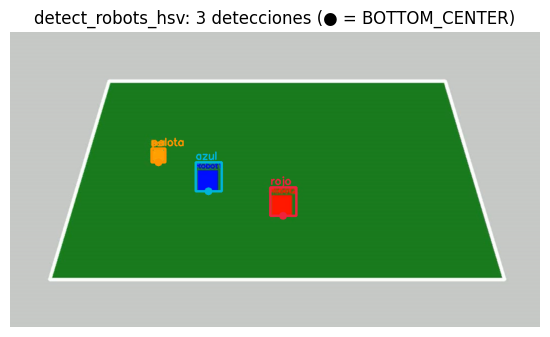

In [3]:
# Visualizar detecciones sobre la imagen
vis = image_rgb.copy()
for box, cid in zip(dets.xyxy, dets.class_id):
    x1, y1, x2, y2 = box.astype(int)
    color_bgr = COLORS_BGR[cid]
    color_rgb = (color_bgr[2], color_bgr[1], color_bgr[0])
    cv2.rectangle(vis, (x1, y1), (x2, y2), color_rgb, 3)
    cx, cy = (x1 + x2) // 2, y2
    cv2.circle(vis, (cx, cy), 8, color_rgb, -1)  # BOTTOM_CENTER
    cv2.putText(vis, CLASS_NAMES[cid], (x1, y1 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_rgb, 2)

plt.figure(figsize=(5.6, 10))
plt.imshow(vis)
plt.title(f"detect_robots_hsv: {len(dets)} detecciones (● = BOTTOM_CENTER)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
def project_detections(detections: sv.Detections, H: np.ndarray) -> list:
    """
    Proyecta el BOTTOM_CENTER de cada bbox al campo canónico.
    Para el balón (class_id=2) usa el centro geométrico.
    """
    puntos = []
    for box, cid in zip(detections.xyxy, detections.class_id):
        if int(cid) == 2:          # balón: centro geométrico
            cx = (box[0] + box[2]) / 2
            cy = (box[1] + box[3]) / 2
        else:                      # robots: bottom center
            cx = (box[0] + box[2]) / 2
            cy = box[3]
        pt = np.float32([[cx, cy]])
        proj = cv2.perspectiveTransform(pt.reshape(1, 1, 2), H)
        puntos.append({
            "pos": (int(proj[0][0][0]), int(proj[0][0][1])),
            "class_id": int(cid),
        })
    return puntos

puntos_canon = project_detections(dets, H)
print("Proyecciones al campo canónico:")
for p in puntos_canon:
    print(f"  {CLASS_NAMES[p['class_id']]:5s}: {p['pos']}")

Proyecciones al campo canónico:
  azul : (159, 230)
  rojo : (250, 271)
  pelota: (89, 164)


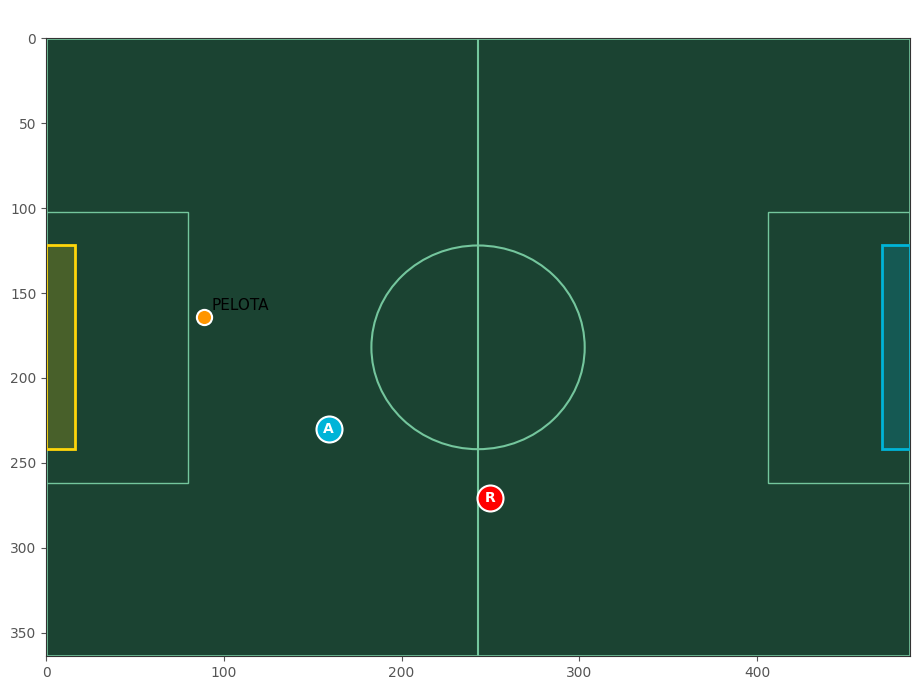

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_tactical_auto(puntos_canon: list,
                               campo_w: int = CAMPO_W, campo_h: int = CAMPO_H,
                               title: str = "Mapa táctico — detección automática HSV") -> None:
    """Dibuja el campo canónico de forma HORIZONTAL con posiciones detectadas automáticamente."""
    
    fig, ax = plt.subplots(figsize=(9.3, 7))
    ax.set_facecolor("#1b4332")
    
    ax.set_xlim(0, campo_w)
    ax.set_ylim(campo_h, 0)

    ax.add_patch(mpatches.Rectangle((0, 0), campo_w, campo_h,
                                 lw=2, edgecolor="#74c69d", facecolor="none"))
    ax.axvline(x=campo_w / 2, color="#74c69d", lw=1.5)
    ax.add_patch(plt.Circle((campo_w / 2, campo_h / 2), int(30 * ESCALA_PX_CM),
                                 color="#74c69d", fill=False, lw=1.5))
    
    pen_w, pen_h = int(40 * ESCALA_PX_CM), int(80 * ESCALA_PX_CM)  
    pen_y = (campo_h - pen_h) / 2
    
    for x_pen in (0, campo_w - pen_w):
        ax.add_patch(mpatches.Rectangle((x_pen, pen_y), pen_w, pen_h,
                                     lw=1, edgecolor="#74c69d", facecolor="none"))
        
    goal_w = int(8 * ESCALA_PX_CM)  
    goal_h = int(60 * ESCALA_PX_CM)  
    goal_y = (campo_h - goal_h) / 2
    
    # Portería Izquierda (Amarilla)
    ax.add_patch(mpatches.Rectangle((0, goal_y), goal_w, goal_h,
                                 lw=2, edgecolor="#ffd60a", facecolor="#ffd60a33"))
    # Portería Derecha (Azul)
    ax.add_patch(mpatches.Rectangle((campo_w - goal_w, goal_y), goal_w, goal_h,
                                 lw=2, edgecolor="#00b4d8", facecolor="#00b4d833"))

    # 8. Dibujamos los puntos de los robots y el balón
    for p in puntos_canon:
        x, y = p["pos"]
        cid  = p["class_id"]
        color = COLORS_HEX[cid]
        size  = 120 if cid == 2 else 350
        ax.scatter(x, y, s=size, c=color, zorder=5,
                   edgecolors="white", linewidths=1.5)
        if cid != 2:
            lbl = "A" if cid == 0 else "R"
            ax.text(x, y, lbl, ha="center", va="center",
                    fontsize=10, fontweight="bold", color="white", zorder=6)
        else:
            ax.text(x + 4, y - 4, "PELOTA", fontsize=11, zorder=6)

    # Estética del gráfico
    ax.set_title(title, fontsize=13, color="white", pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
    ax.tick_params(colors="#555")
    plt.tight_layout()
    plt.show()

# Llamamos a tu nueva función horizontal
draw_tactical_auto(puntos_canon)

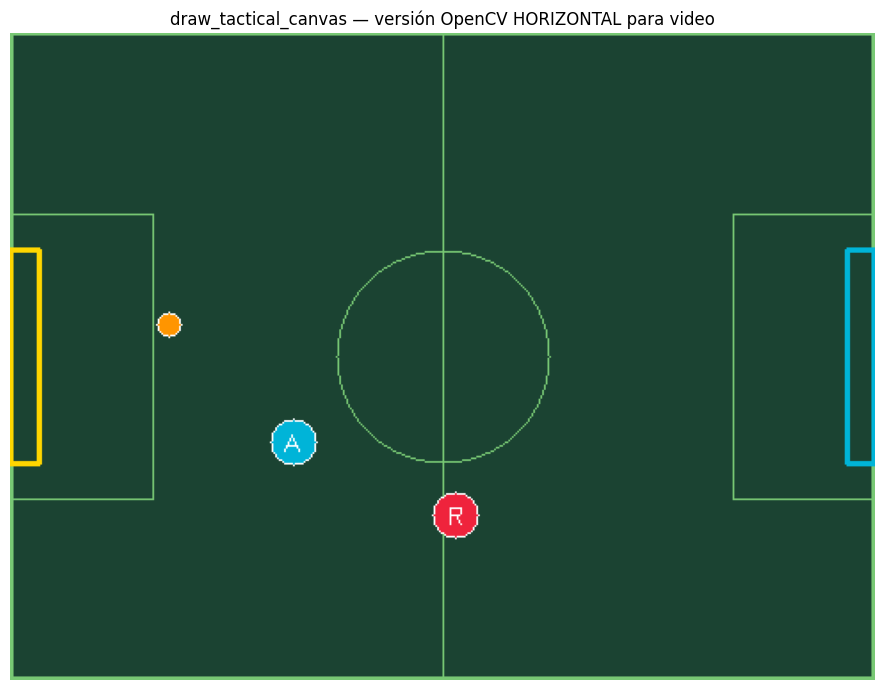

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def draw_tactical_canvas(puntos_canon: list,
                                    campo_w: int = CAMPO_W,
                                    campo_h: int = CAMPO_H) -> np.ndarray:
    """Dibuja el mapa táctico como imagen BGR HORIZONTAL (para incrustar en video)."""
    # 1. Lienzo 
    canvas = np.zeros((campo_h, campo_w, 3), dtype=np.uint8)
    canvas[:] = (50, 67, 27)  

    # 2. Borde
    cv2.rectangle(canvas, (0, 0), (campo_w - 1, campo_h - 1), (116, 200, 120), 2)
    
    # 3. Línea media
    cv2.line(canvas, (campo_w // 2, 0), (campo_w // 2, campo_h), (116, 200, 120), 1)
    
    # 4. Círculo central
    cv2.circle(canvas, (campo_w // 2, campo_h // 2), int(30 * ESCALA_PX_CM), (116, 200, 120), 1)

    # 5. Penales
    pen_w = int(40 * ESCALA_PX_CM)  
    pen_h = int(80 * ESCALA_PX_CM)  
    pen_y = (campo_h - pen_h) // 2
    
    cv2.rectangle(canvas, (0, pen_y), (pen_w, pen_y + pen_h), (116, 200, 120), 1)
    cv2.rectangle(canvas, (campo_w - pen_w, pen_y), (campo_w - 1, pen_y + pen_h), (116, 200, 120), 1)

    # 6. Porterías
    goal_w_px = int(8 * ESCALA_PX_CM)   
    goal_h_px = int(60 * ESCALA_PX_CM) 
    goal_y_px = (campo_h - goal_h_px) // 2
    
    cv2.rectangle(canvas, (0, goal_y_px), (goal_w_px, goal_y_px + goal_h_px), (0, 214, 255), 2)
    cv2.rectangle(canvas, (campo_w - goal_w_px, goal_y_px), (campo_w - 1, goal_y_px + goal_h_px), (216, 180, 0), 2)

    # 7. Puntos proyectados
    for p in puntos_canon:
        x, y = p["pos"]
        cid  = p["class_id"]
        
        if not (0 <= x < campo_w and 0 <= y < campo_h):
            continue
            
        color = COLORS_BGR[cid]
        r = 7 if cid == 2 else 13
        
        cv2.circle(canvas, (x, y), r, color, -1)
        cv2.circle(canvas, (x, y), r, (255, 255, 255), 1) # Borde blanco elegante
        
        if cid != 2:
            lbl = "A" if cid == 0 else "R"
            cv2.putText(canvas, lbl, (x - 5, y + 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
    return canvas

tactical_bgr_horiz = draw_tactical_canvas(puntos_canon)
plt.figure(figsize=(9.3, 7)) 
plt.imshow(cv2.cvtColor(tactical_bgr_horiz, cv2.COLOR_BGR2RGB))
plt.title("draw_tactical_canvas — versión OpenCV HORIZONTAL para video")
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
def callback_nb11(frame: np.ndarray, _: int) -> np.ndarray:
    dets = detect_robots_hsv(frame)
    # 2. Proyectar al campo canónico
    puntos = project_detections(dets, H)
    # 3. Vista cenital (warp)
    warped = cv2.warpPerspective(frame, H, (CAMPO_W, CAMPO_H))
    # 4. Mapa táctico como canvas OpenCV
    tactical = draw_tactical_canvas(puntos)
    # 5. Frame original redimensionado para igualar altura
    escala  = CAMPO_H / frame.shape[0]
    orig_w  = int(frame.shape[1] * escala)
    resized = cv2.resize(frame, (orig_w, CAMPO_H))
    # Dibujar bboxes sobre el frame redimensionado
    for box, cid in zip(dets.xyxy, dets.class_id):
        x1, y1, x2, y2 = (box * escala).astype(int)
        cv2.rectangle(resized, (x1, y1), (x2, y2), COLORS_BGR[cid], 2)
    return np.hstack([resized, warped, tactical])

INPUT_VIDEO = DIR_ACTUAL / "videos/futbot-3.mp4"
OUTPUT_VIDEO = DIR_ACTUAL / "videos/futbot_nb11.mp4"
cap_in = cv2.VideoCapture(str(INPUT_VIDEO))
ret, primer_frame = cap_in.read()

if not ret:
    print('Ruta no válida ',  INPUT_VIDEO)
else:
    cap_in.set(cv2.CAP_PROP_POS_FRAMES, 0)
    
    escala = CAMPO_H / primer_frame.shape[0]
    orig_w = int(primer_frame.shape[1] * escala)
    
    ANCHO_FINAL = orig_w + CAMPO_W + CAMPO_W
    ALTO_FINAL  = CAMPO_H
    
    fps = cap_in.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    cap_out = cv2.VideoWriter(str(OUTPUT_VIDEO), fourcc, fps, (ANCHO_FINAL, ALTO_FINAL))

    while cap_in.isOpened():
        ret, frame = cap_in.read()
        
        if not ret:
            break

        current = callback_nb11(frame, 0)
        cap_out.write(current)

    cap_in.release()
    cap_out.release()


print(f"✅ Video guardado: {OUTPUT_VIDEO}")

✅ Video guardado: c:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\assets\videos\futbot_nb11.mp4


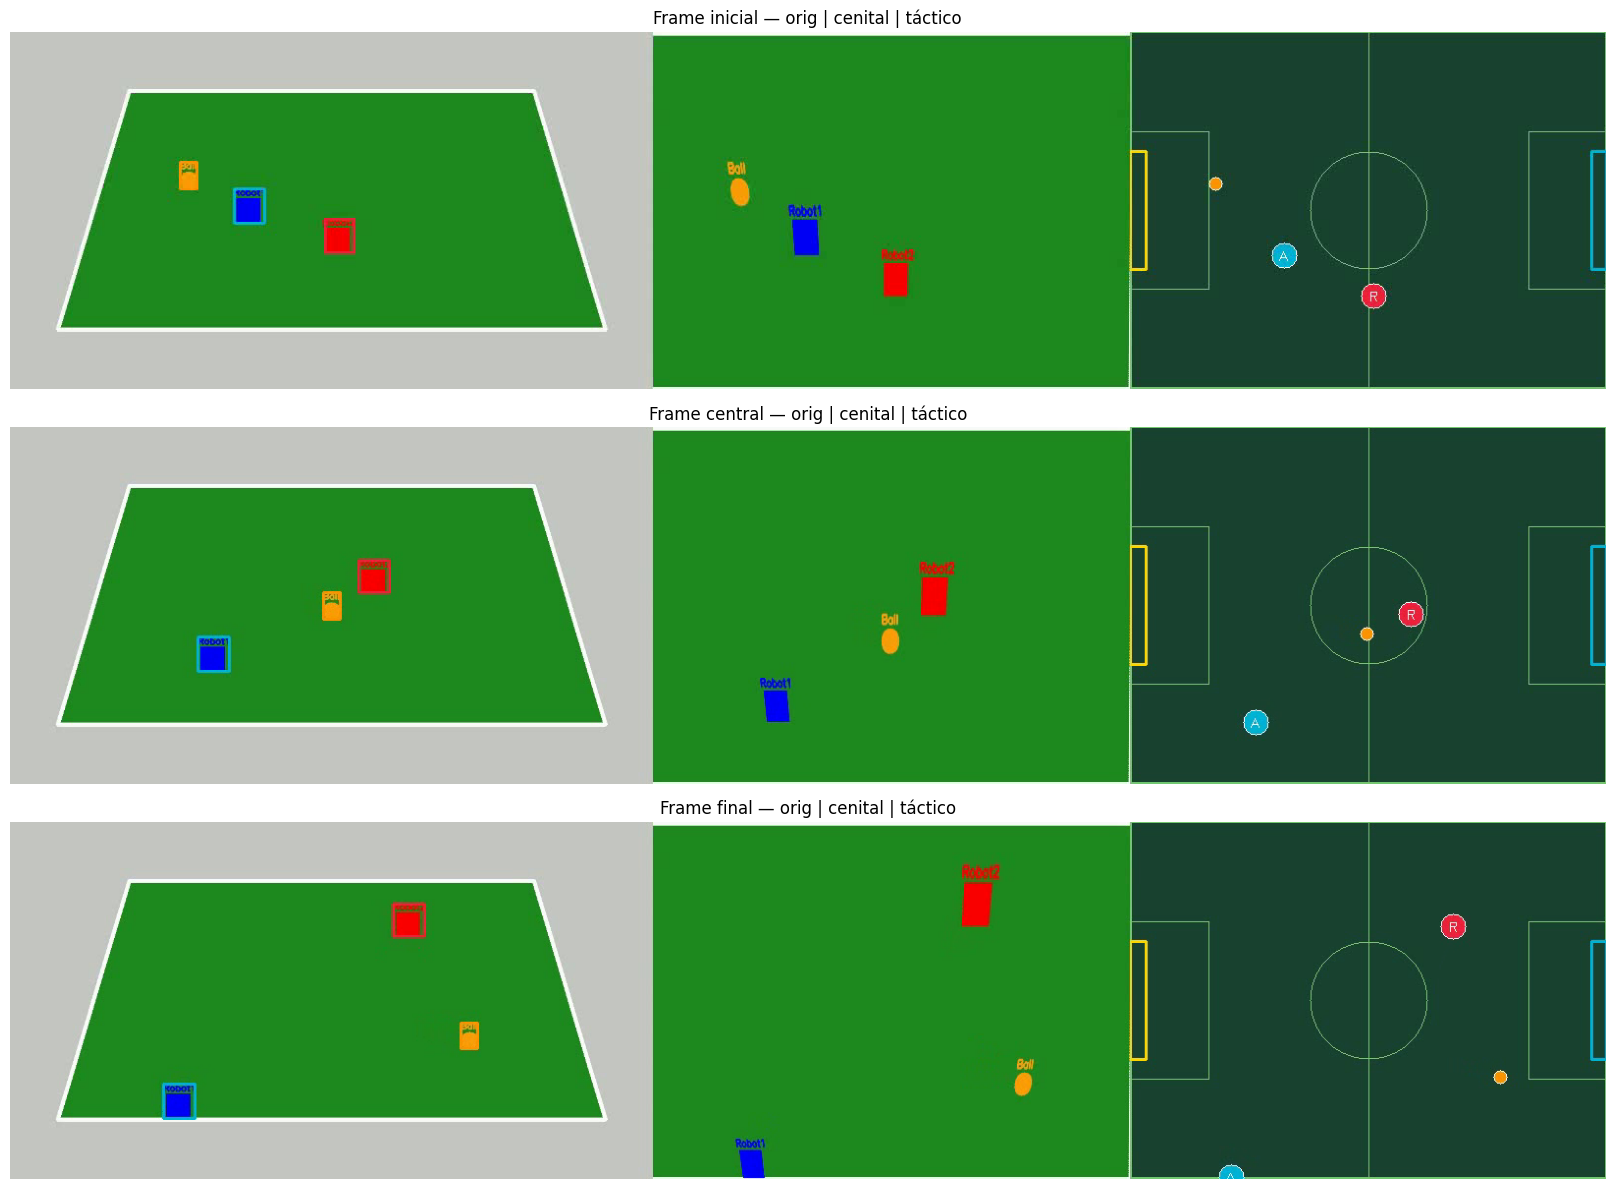

In [8]:
cap = cv2.VideoCapture(OUTPUT_VIDEO)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frames_vis = {}
for idx in (0, n_frames // 2, n_frames - 1):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frames_vis[idx] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
cap.release()

_sample = next(iter(frames_vis.values()))
_h, _w = _sample.shape[:2]
_dh = 4
fig, axes = plt.subplots(len(frames_vis), 1,
                         figsize=(_dh * _w / _h, _dh * len(frames_vis)))
titles = ["Frame inicial", "Frame central", "Frame final"]
for ax, (idx, frgb), title in zip(axes, frames_vis.items(), titles):
    ax.imshow(frgb)
    ax.set_title(f"{title} — orig | cenital | táctico")
    ax.axis("off")
plt.tight_layout()
plt.show()

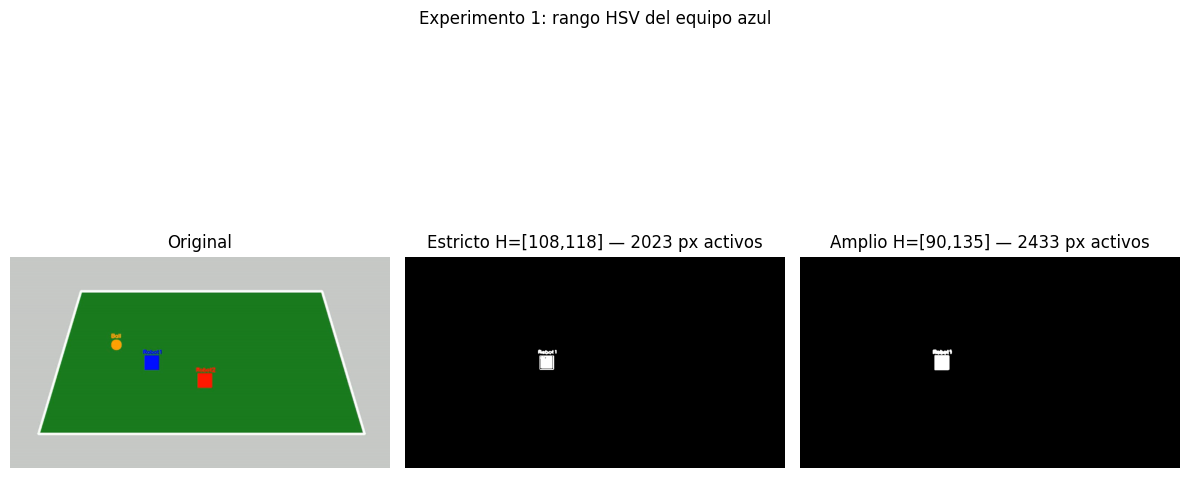

In [9]:
hsv_img = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

mask_estricto = cv2.inRange(hsv_img, np.array([108, 120, 80]),
                                     np.array([118, 255, 255]))
mask_amplio   = cv2.inRange(hsv_img, np.array([ 90,  50, 40]),
                                     np.array([135, 255, 255]))

fig, axes = plt.subplots(1, 3, figsize=(12, 7))
axes[0].imshow(image_rgb);        axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(mask_estricto, cmap="gray")
axes[1].set_title(f"Estricto H=[108,118] — {mask_estricto.sum()//255} px activos")
axes[1].axis("off")
axes[2].imshow(mask_amplio, cmap="gray")
axes[2].set_title(f"Amplio H=[90,135] — {mask_amplio.sum()//255} px activos")
axes[2].axis("off")
plt.suptitle("Experimento 1: rango HSV del equipo azul", fontsize=12)
plt.tight_layout(); plt.show()

In [10]:
for min_area in (100, 300, 500, 1500):
    d = detect_robots_hsv(image_bgr, min_area=min_area)
    n_azul = sum(1 for c in d.class_id if c == 0)
    n_rojo = sum(1 for c in d.class_id if c == 1)
    n_balon = sum(1 for c in d.class_id if c == 2)
    print(f"min_area={min_area:5d} → total={len(d):2d}  "
          f"(azul={n_azul}, rojo={n_rojo}, balón={n_balon})")

min_area=  100 → total= 4  (azul=1, rojo=1, balón=2)
min_area=  300 → total= 4  (azul=1, rojo=1, balón=2)
min_area=  500 → total= 3  (azul=1, rojo=1, balón=1)
min_area= 1500 → total= 2  (azul=1, rojo=1, balón=0)


In [11]:
from trackers import ByteTrackTracker

tracker = ByteTrackTracker()
DIR_COMPUESTO = DIR_ACTUAL / "videos/futbot-02.mp4"
cap = cv2.VideoCapture(str(DIR_COMPUESTO))
print(DIR_COMPUESTO)

ids_por_frame = []
for i in range(15):
    ret, frame = cap.read()
    if not ret:
        break
    d = detect_robots_hsv(frame)
    if len(d) > 0:
        d = tracker.update(d)
        ids = [int(x) for x in d.tracker_id] if d.tracker_id is not None else []
    else:
        ids = []
    ids_por_frame.append((i, ids))
cap.release()

print("tracker_id por frame (primeros 15 frames):")
for i, ids in ids_por_frame:
    print(f"  Frame {i:02d}: {ids}")

c:\Users\m0nda\Visual Studio\Projects\futbot\notebooks\assets\videos\futbot-02.mp4
tracker_id por frame (primeros 15 frames):
  Frame 00: [-1, -1]
  Frame 01: [0, 1]
  Frame 02: [0, 1]
  Frame 03: [0, 1]
  Frame 04: [0, 1]
  Frame 05: [0, 1]
  Frame 06: [0, 1]
  Frame 07: [0, 1]
  Frame 08: [0, 1]
  Frame 09: [0, 1]
  Frame 10: [0, 1]
  Frame 11: [0, 1]
  Frame 12: [0, 1]
  Frame 13: [0, 1]
  Frame 14: [0, 1]


In [12]:
def dist_cm(p1: tuple, p2: tuple, escala: float = ESCALA_PX_CM) -> float:
    """Distancia euclidiana entre dos puntos canónicos, en centímetros reales."""
    dx = (p2[0] - p1[0]) / escala
    dy = (p2[1] - p1[1]) / escala
    return float(np.sqrt(dx**2 + dy**2))

# Leer 2 frames consecutivos del video de entrada para estimar velocidad
cap_exp = cv2.VideoCapture(str(DIR_COMPUESTO))
frames_exp = []
for _ in range(2):
    ret, frm = cap_exp.read()
    if ret:
        frames_exp.append(frm)
cap_exp.release()

if len(frames_exp) == 2:
    pts0 = project_detections(detect_robots_hsv(frames_exp[0]), H)
    pts1 = project_detections(detect_robots_hsv(frames_exp[1]), H)
    print(f"Campo: {CAMPO_W/ESCALA_PX_CM:.0f} × {CAMPO_H/ESCALA_PX_CM:.0f} cm real")
    print()
    # Distancias entre objetos en frame 0
    for i, pi in enumerate(pts0):
        for j, pj in enumerate(pts0):
            if j <= i:
                continue
            d = dist_cm(pi["pos"], pj["pos"])
            print(f"  {CLASS_NAMES[pi['class_id']]} → {CLASS_NAMES[pj['class_id']]}: {d:.1f} cm")
    print()
    # Velocidad del primer objeto detectado entre frame 0 y frame 1
    if pts0 and pts1:
        v = dist_cm(pts0[0]["pos"], pts1[0]["pos"]) * 30.0  # 30 fps
        print(f"  {CLASS_NAMES[pts0[0]['class_id']]} vel. entre frames: {v:.1f} cm/s  ({v/100:.2f} m/s)")
else:
    print("No se pudo leer el video — verifica la ruta de assets/futbot-2s.mp4")

Campo: 243 × 182 cm real

  azul → pelota: 50.2 cm

  azul vel. entre frames: 33.5 cm/s  (0.34 m/s)


In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

def detect_with_yolo(frame_bgr: np.ndarray, idx: int) -> sv.Detections:
    results = model(frame_bgr, conf=0.3, verbose=False)[0]
    return sv.Detections.from_ultralytics(results)
    
INPUT_VIDEO = DIR_ACTUAL / "videos/futbot-3.mp4"
OUTPUT_VIDEO = DIR_ACTUAL / "videos/futbot_yolo.mp4"

sv.process_video(
    source_path=INPUT_VIDEO,
    target_path=OUTPUT_VIDEO,
    callback=detect_with_yolo
)

print("detect_with_yolo definida. Intercambio de detectores — mismo pipeline, distinta fuente:")
print("  NB11 (color):", "detect_robots_hsv(frame)  → sv.Detections")
print("  Reto (YOLO): ", "detect_with_yolo(frame)   → sv.Detections")
print("  project_detections() y draw_tactical_canvas() no cambian.")

Exception in thread Thread-5 (writer_thread):
Traceback (most recent call last):
  File "c:\Users\m0nda\miniconda3\envs\supervision\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\m0nda\miniconda3\envs\supervision\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\m0nda\miniconda3\envs\supervision\Lib\site-packages\supervision\utils\video.py", line 305, in writer_thread
    video_sink.write_frame(frame=frame)
  File "c:\Users\m0nda\miniconda3\envs\supervision\Lib\site-packages\supervision\utils\video.py", line 124, in write_frame
    self.__writer.write(frame)
cv2.error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'write'
> Overload resolution failed:
>  - image is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'image'

